# Intrusion Detection using Machine Learning on ALLFLOWMETER_HIKARI2021

## Objective
The objective of this notebook is to build and evaluate supervised Machine Learning models capable of detecting malicious network traffic using the **ALLFLOWMETER_HIKARI2021** dataset.

The target variable is `Label`, where the expected interpretation is:

- `0` = benign traffic
- `1` = malicious / attack traffic

This work follows the AI for Cybersecurity workflow: dataset understanding, preprocessing, model training, evaluation, and cybersecurity interpretation.


## Research question

**Can supervised Machine Learning models accurately distinguish benign network flows from malicious network flows using flow-based features from the ALLFLOWMETER_HIKARI2021 dataset?**

From a cybersecurity perspective, the most critical operational requirement is not only high global accuracy, but also strong **attack recall**, because false negatives represent attacks that the IDS fails to detect.


## Dataset description

The ALLFLOWMETER_HIKARI2021 dataset contains network-flow features extracted from traffic captures. Each row represents a network flow and includes statistical traffic features such as packet counts, byte counts, duration, inter-arrival timing, and protocol behaviour.

This dataset is relevant for cybersecurity because it supports the development of **Intrusion Detection Systems (IDS)**. In this context, Machine Learning models learn patterns that differentiate benign activity from suspicious or malicious traffic.

The notebook assumes that the dataset file is available in one of the following locations:

- `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`
- `data/raw/ALLFLOWMETER_HIKARI2021.csv`
- `ALLFLOWMETER_HIKARI2021.csv`

Update the path in the next cell if your local project structure is different.


## 1. Environment setup and imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## 2. Load dataset

This cell searches common project paths and loads the CSV file. This makes the notebook easier to execute in VS Code, Jupyter, or GitHub Codespaces.


In [2]:
candidate_paths = [
    Path("../../data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("ALLFLOWMETER_HIKARI2021.csv")
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place ALLFLOWMETER_HIKARI2021.csv in ../../data/raw/, data/raw/, "
        "or the notebook folder."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()


Loading dataset from: ../../data/raw/ALLFLOWMETER_HIKARI2021.csv


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

## 3. Initial dataset inspection

This section validates the dataset structure, number of rows and columns, data types, missing values, duplicates, and available labels.


In [4]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes.value_counts())

print("First rows:")
display(df.head())


Dataset shape: (555278, 88)
Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'originh', 'originp', 'responh', 'responp', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pk

float64    56
int64      28
str         4
Name: count, dtype: int64

First rows:


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

In [6]:
print("Dataset info:")
df.info()

missing_values = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing_values.sum()))
display(missing_values[missing_values > 0].head(20))

print("Duplicated rows:", int(df.duplicated().sum()))


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 555278 entries, 0 to 555277
Data columns (total 88 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.1              555278 non-null  int64  
 1   Unnamed: 0                555278 non-null  int64  
 2   uid                       555278 non-null  str    
 3   originh                   555278 non-null  str    
 4   originp                   555278 non-null  int64  
 5   responh                   555278 non-null  str    
 6   responp                   555278 non-null  int64  
 7   flow_duration             555278 non-null  float64
 8   fwd_pkts_tot              555278 non-null  int64  
 9   bwd_pkts_tot              555278 non-null  int64  
 10  fwd_data_pkts_tot         555278 non-null  int64  
 11  bwd_data_pkts_tot         555278 non-null  int64  
 12  fwd_pkts_per_sec          555278 non-null  float64
 13  bwd_pkts_per_sec          555278 non-null

Series([], dtype: int64)

Duplicated rows: 0


## 4. Label and traffic category analysis

Before training a model, it is critical to understand the target variable and the traffic categories. IDS datasets are frequently imbalanced, and imbalance can distort accuracy.


In [7]:
label_related_cols = df.columns[df.columns.str.contains("category|label|traffic", case=False, regex=True)]
label_related_cols.tolist()


['traffic_category', 'Label']

In [8]:
if "Label" not in df.columns:
    raise KeyError("Expected target column 'Label' was not found in the dataset.")

label_counts = df["Label"].value_counts().sort_index()
label_percent = df["Label"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({"count": label_counts, "percentage": label_percent.round(2)})
display(label_summary)


,count,percentage
Label,,
0,517582,93.21
1,37696,6.79


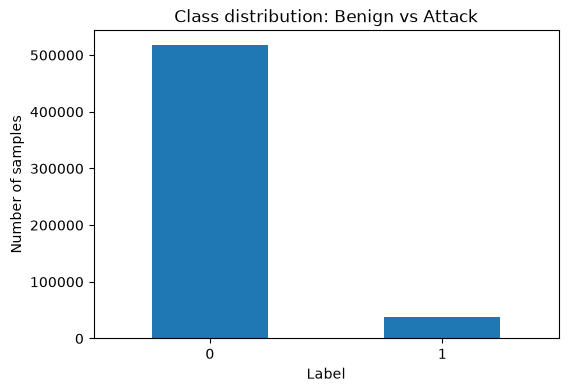

In [9]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Class distribution: Benign vs Attack")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()


,count,percentage
traffic_category,,
Benign,347431,62.57
Background,170151,30.64
Probing,23388,4.21
Bruteforce,5884,1.06
Bruteforce-XML,5145,0.93
XMRIGCC CryptoMiner,3279,0.59


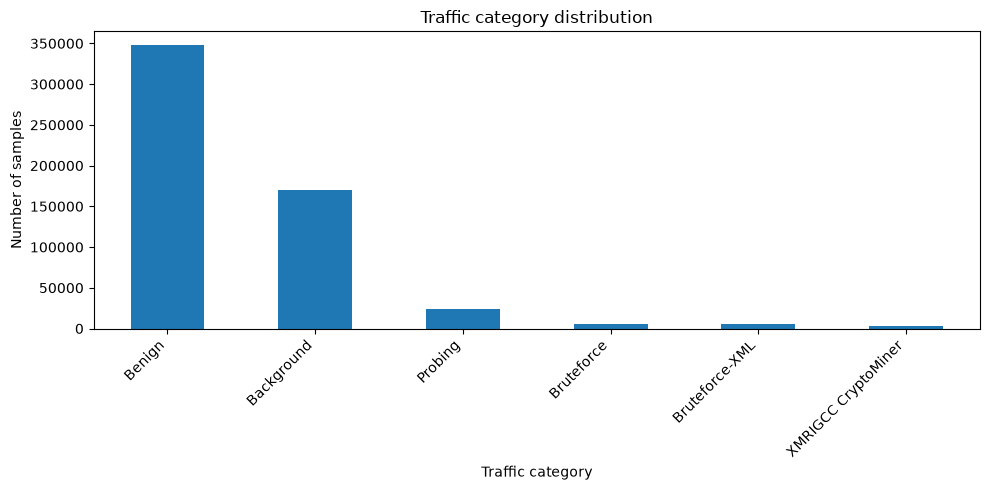

Label,0,1
traffic_category,,
Background,170151,0
Benign,347431,0
Bruteforce,0,5884
Bruteforce-XML,0,5145
Probing,0,23388
XMRIGCC CryptoMiner,0,3279


In [10]:
if "traffic_category" in df.columns:
    traffic_summary = pd.DataFrame({
        "count": df["traffic_category"].value_counts(),
        "percentage": (df["traffic_category"].value_counts(normalize=True) * 100).round(2)
    })
    display(traffic_summary)

    plt.figure(figsize=(10, 5))
    df["traffic_category"].value_counts().plot(kind="bar")
    plt.title("Traffic category distribution")
    plt.xlabel("Traffic category")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(df["traffic_category"], df["Label"]))
else:
    print("Column 'traffic_category' not found. Skipping traffic category analysis.")


## 5. Quick dataset summary

This summary is useful for the report and for documenting reproducibility.


In [11]:
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicates": int(df.duplicated().sum()),
    "missing_values_total": int(df.isna().sum().sum()),
    "target_column": "Label",
    "number_of_classes": int(df["Label"].nunique())
}

summary


{'rows': 555278,
 'columns': 88,
 'duplicates': 0,
 'missing_values_total': 0,
 'target_column': 'Label',
 'number_of_classes': 2}

## 6. Feature preparation

Non-numeric identifiers and categorical descriptors are removed from the model input. This avoids training the model on fields that may not generalize well, such as unique IDs or host identifiers.

The target variable remains `Label`.


In [12]:
target_col = "Label"

drop_cols = [
    "Unnamed: 0.1",
    "Unnamed: 0",
    "uid",
    "originh",
    "responh",
    "traffic_category",
    "Label"
]

X_raw = df.drop(columns=drop_cols, errors="ignore")
y = df[target_col].astype(int)

X = X_raw.select_dtypes(include=["number"]).copy()

print("Original feature matrix shape:", X_raw.shape)
print("Numeric feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of selected numeric features:", X.shape[1])
display(X.head())


Original feature matrix shape: (555278, 81)
Numeric feature matrix shape: (555278, 81)
Target shape: (555278,)
Number of selected numeric features: 81


,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,1.000000,432,20,40,480,32,44,2,2,2,6,5,25,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,358.928571,792.173394,0.0,2896.0,6853.0,244.750000,583.468215,16.927719,7.545305e+06,

## 7. Cleaning missing and infinite values

Machine Learning models cannot handle missing or infinite values directly. Infinite values are converted to missing values and then replaced using the median of each numeric feature.


In [13]:
X = X.replace([np.inf, -np.inf], np.nan)

missing_before = int(X.isna().sum().sum())
X = X.fillna(X.median(numeric_only=True))
missing_after = int(X.isna().sum().sum())

print("Missing values before cleaning:", missing_before)
print("Missing values after cleaning:", missing_after)


Missing values before cleaning: 0
Missing values after cleaning: 0


## 8. Exploratory feature analysis

Correlation with the target provides a first indication of which features may be informative. This is not a complete feature-selection method, but it helps interpret the dataset before modelling.


In [14]:
numeric_df = pd.concat([X, y.rename("Label")], axis=1)
correlations = numeric_df.corr(numeric_only=True)["Label"].abs().sort_values(ascending=False)

display(correlations.head(16))


Label                    1.000000
bwd_init_window_size     0.321053
bwd_header_size_max      0.291120
fwd_pkts_payload.std     0.283017
bwd_header_size_min      0.281358
fwd_pkts_payload.max     0.265688
bwd_bulk_rate            0.249869
flow_RST_flag_count      0.244015
flow_SYN_flag_count      0.239297
flow_FIN_flag_count      0.231533
fwd_header_size_max      0.220685
fwd_init_window_size     0.214189
fwd_pkts_payload.avg     0.208203
bwd_pkts_payload.std     0.200748
flow_pkts_payload.std    0.194539
flow_pkts_payload.avg    0.182477
Name: Label, dtype: float64

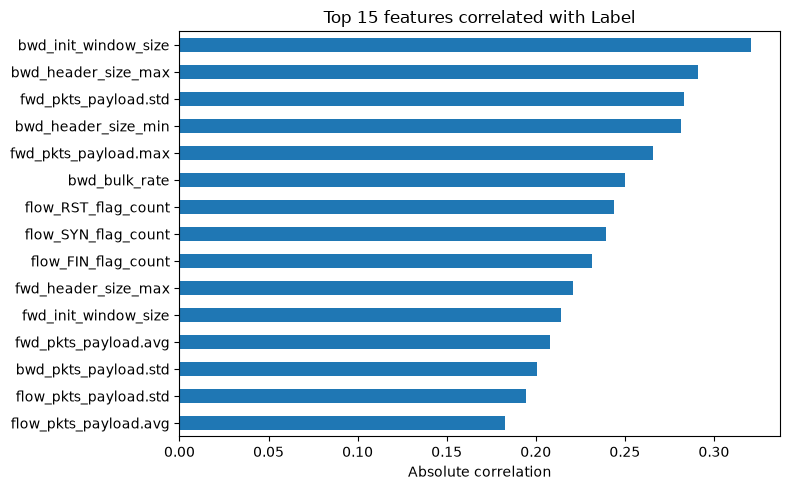

In [15]:
top_corr = correlations.drop("Label", errors="ignore").head(15).sort_values()

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh")
plt.title("Top 15 features correlated with Label")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()


## 9. Train/test split

A stratified split is used to preserve the original class distribution in both training and test sets. This is important for imbalanced IDS datasets.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:")
display(y_train.value_counts(normalize=True).sort_index().rename("train_percentage") * 100)
print("Testing labels:")
display(y_test.value_counts(normalize=True).sort_index().rename("test_percentage") * 100)


Training features: (444222, 81)
Testing features: (111056, 81)
Training labels:


Label
0    93.211277
1     6.788723
Name: train_percentage, dtype: float64

Testing labels:


Label
0    93.211533
1     6.788467
Name: test_percentage, dtype: float64

## 10. Scaling for Logistic Regression

Logistic Regression is sensitive to feature scale. Standardization is fitted only on the training data and then applied to the test data to avoid data leakage.


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 11. Model 1 — Logistic Regression

Logistic Regression is used as an interpretable baseline classifier. `class_weight="balanced"` helps compensate for class imbalance.


In [18]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_score_log = log_model.predict_proba(X_test_scaled)[:, 1]


/Users/sergiofaria/Documents/AI4Cyber_HIKARI_IDS/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 12. Model 2 — Random Forest

Random Forest is an ensemble of decision trees and is commonly used as a strong baseline for tabular IDS datasets. It can model non-linear relationships and provides feature-importance values.


In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]


## 13. Evaluation methodology

The following metrics are used:

- **Accuracy**: global percentage of correct predictions.
- **Precision**: among predicted attacks, how many were really attacks.
- **Recall**: among real attacks, how many were detected.
- **F1-score**: balance between precision and recall.
- **ROC-AUC**: ranking quality across decision thresholds.
- **PR-AUC**: especially useful when attack traffic is imbalanced.

For IDS use cases, **recall for the attack class is operationally critical**, because false negatives represent undetected attacks.


In [21]:
def evaluate_model(model_name, y_true, y_pred, y_score):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return results


In [22]:
results_log = evaluate_model("Logistic Regression", y_test, y_pred_log, y_score_log)
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_score_rf)

results_df = pd.DataFrame([results_log, results_rf])
results_df.set_index("Model").round(4)


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    103517
           1       0.31      0.99      0.47      7539

    accuracy                           0.85    111056
   macro avg       0.65      0.91      0.69    111056
weighted avg       0.95      0.85      0.88    111056

Confusion Matrix:
[[86468 17049]
 [   57  7482]]
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    103517
           1       0.23      0.38      0.29      7539

    accuracy                           0.87    111056
   macro avg       0.59      0.64      0.61    111056
weighted avg       0.90      0.87      0.89    111056

Confusion Matrix:
[[94213  9304]
 [ 4708  2831]]


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.8460,0.3050,0.9924,0.4666,0.9342,0.3774
Random Forest,0.8738,0.2333,0.3755,0.2878,0.8984,0.2359


## 14. Confusion matrices

The confusion matrix is essential for IDS interpretation:

- **True Positive (TP)**: attack correctly detected.
- **False Positive (FP)**: benign traffic incorrectly flagged as attack.
- **False Negative (FN)**: attack missed by the model.
- **True Negative (TN)**: benign traffic correctly classified.

False negatives are the highest-risk error in intrusion detection.


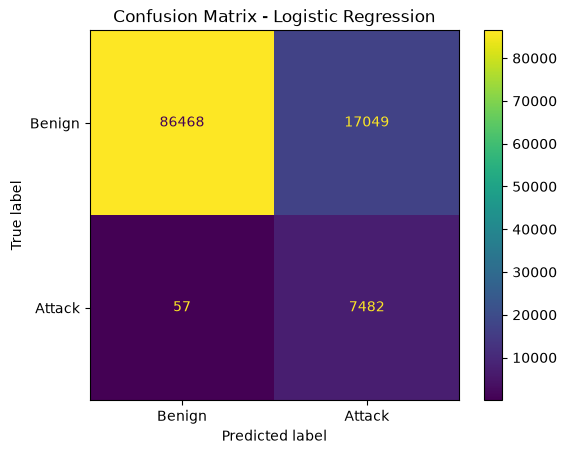

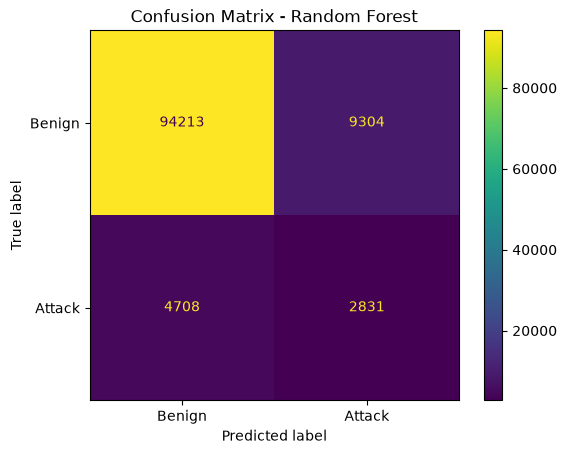

In [23]:
for model_name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Random Forest", y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


## 15. ROC and Precision-Recall curves

These curves help compare models independently of a fixed threshold. PR curves are especially relevant when the positive class is less frequent.


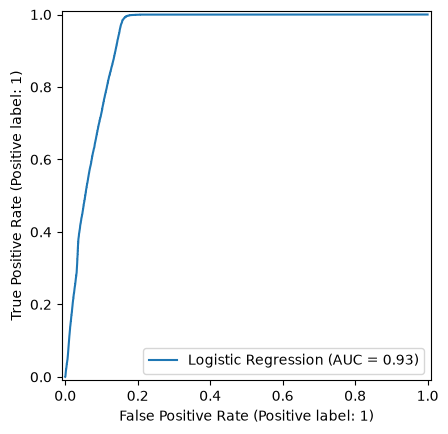

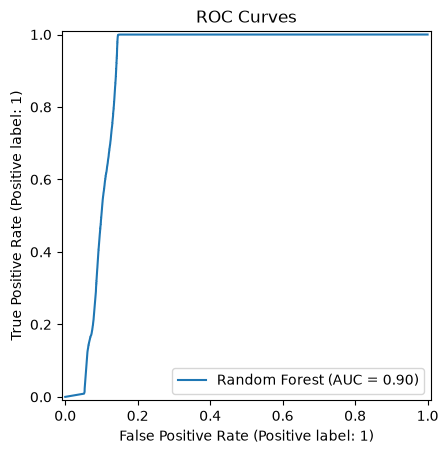

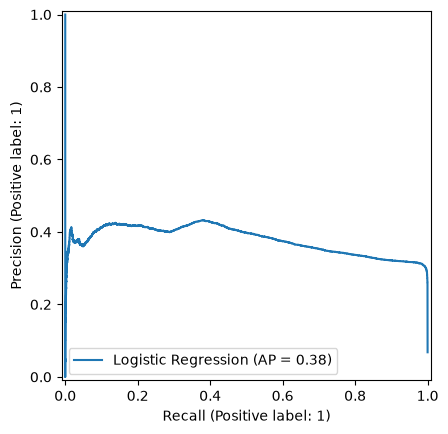

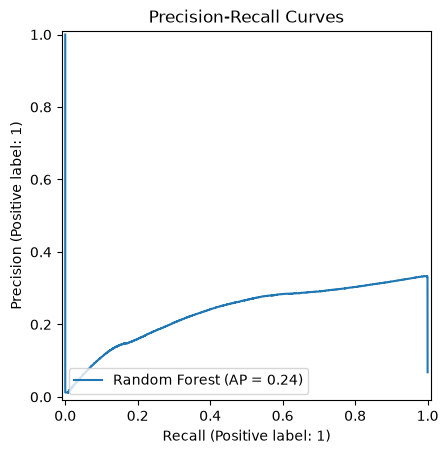

In [24]:
RocCurveDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("ROC Curves")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("Precision-Recall Curves")
plt.show()


## 16. Random Forest feature importance

Feature importance helps explain which flow characteristics contributed most to the Random Forest decisions. This improves model interpretability and supports the cybersecurity discussion.


In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))


,Feature,Importance
60,fwd_subflow_bytes,0.068364
46,fwd_iat.std,0.058235
5,fwd_data_pkts_tot,0.055313
43,fwd_iat.max,0.052493
70,active.tot,0.050327
79,bwd_init_window_size,0.046848
3,fwd_pkts_tot,0.046132
29,fwd_pkts_payload.tot,0.036277
2,flow_duration,0.035802
44,fwd_iat.tot,0.032809


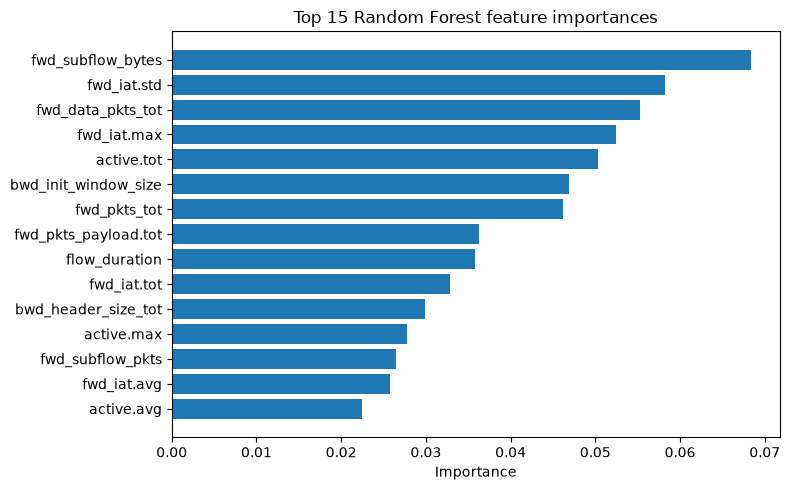

In [26]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 17. Cybersecurity interpretation of results

The final model should not be selected only by accuracy. In an IDS, the business and security impact of each error type is different:

- **False negatives** mean malicious flows are not detected. This can allow compromise, lateral movement, data leakage, or persistence.
- **False positives** mean benign flows are flagged as malicious. This increases alert fatigue and can overload SOC analysts.

A model with high accuracy but weak attack recall may look good statistically but perform poorly in a real security operation. Therefore, the preferred model should balance **high recall** with manageable precision.


## 18. Results discussion

Compare the results produced above and document the operational trade-off.

Suggested interpretation template:

> The Logistic Regression model achieved stronger attack recall, meaning it detected a larger proportion of malicious flows. However, if its precision is low, it also generated many false positives. The Random Forest model may achieve better global accuracy, but if its attack recall is lower, this is a critical weakness for an IDS because more attacks remain undetected.
>
> From a cybersecurity perspective, recall is especially important because missing attacks can have a higher operational impact than generating additional alerts. However, excessive false positives can overload analysts, so the final model must balance recall and precision.

Update this text after executing the notebook and observing the actual metric values.


## 19. Limitations

This notebook has the following limitations:

1. The evaluation uses a single train/test split. Cross-validation would provide a more robust estimate.
2. Only two baseline models are tested. Additional models such as XGBoost, LightGBM, SVM, or MLP could improve results.
3. Hyperparameter tuning is not yet performed.
4. The model is evaluated offline, not in a real-time IDS deployment.
5. The dataset may not fully represent current production network behaviour.
6. Feature removal is based on generic assumptions; a deeper domain-based feature-selection process could improve generalization.


## 20. Future work

Recommended next steps:

- Add hyperparameter tuning using `GridSearchCV`, `RandomizedSearchCV`, or Optuna.
- Test additional algorithms such as XGBoost, LightGBM, SVM, and neural networks.
- Perform cross-validation.
- Optimize the classification threshold to reduce false negatives while controlling false positives.
- Add SHAP or permutation importance for stronger explainability.
- Validate the model on unseen traffic or a different IDS dataset.
- Discuss deployment options: on-premises, cloud, or edge IDS integration.


## 21. Conclusion

This notebook demonstrates a supervised Machine Learning pipeline for intrusion detection using the ALLFLOWMETER_HIKARI2021 dataset.

The work includes dataset inspection, exploratory analysis, preprocessing, model training, model evaluation, and cybersecurity-oriented interpretation. Logistic Regression and Random Forest are used as baseline classifiers.

The key takeaway is that model selection for cybersecurity must consider operational risk. Accuracy alone is insufficient; attack recall, false negatives, false positives, and analyst workload must be considered before selecting a model for IDS deployment.


## References

- HIKARI2021 / ALLFLOWMETER_HIKARI2021 dataset documentation.
- Scikit-learn documentation: supervised learning, Logistic Regression, Random Forest, model evaluation metrics.
- Rui Fernandes, *AI for Cybersecurity* course materials.
- Rui Fernandes, *Scientific Writing - Introduction* course materials.
